,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


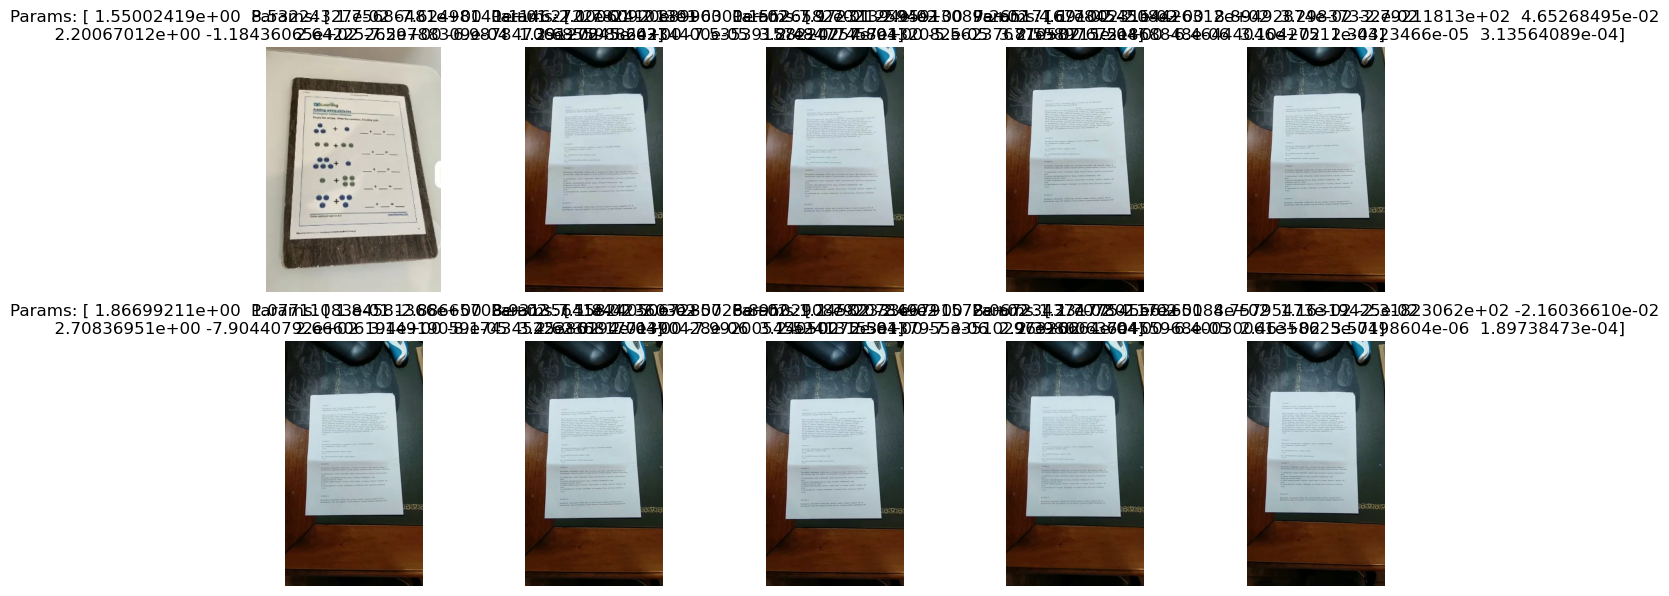

Epoch: 1, Train Loss: 183692.75122070312
Epoch: 2, Train Loss: 118702.13720703125
Epoch: 3, Train Loss: 83437.5224609375
Epoch: 4, Train Loss: 72005.12176513672
Epoch: 5, Train Loss: 55800.072998046875
Epoch: 6, Train Loss: 48040.696533203125
Epoch: 7, Train Loss: 43243.983337402344
Epoch: 8, Train Loss: 38731.94665527344
Epoch: 9, Train Loss: 39122.503845214844
Epoch: 10, Train Loss: 32032.338623046875
Epoch: 11, Train Loss: 38524.679626464844
Epoch: 12, Train Loss: 26822.943969726562
Epoch: 13, Train Loss: 24631.8221282959
Epoch: 14, Train Loss: 17793.421264648438
Epoch: 15, Train Loss: 18201.370544433594
Epoch: 16, Train Loss: 14009.106704711914
Epoch: 17, Train Loss: 12127.514831542969
Epoch: 18, Train Loss: 10536.75357055664
Epoch: 19, Train Loss: 12083.95133972168
Epoch: 20, Train Loss: 9087.433624267578
Test Loss: 10796.549438476562


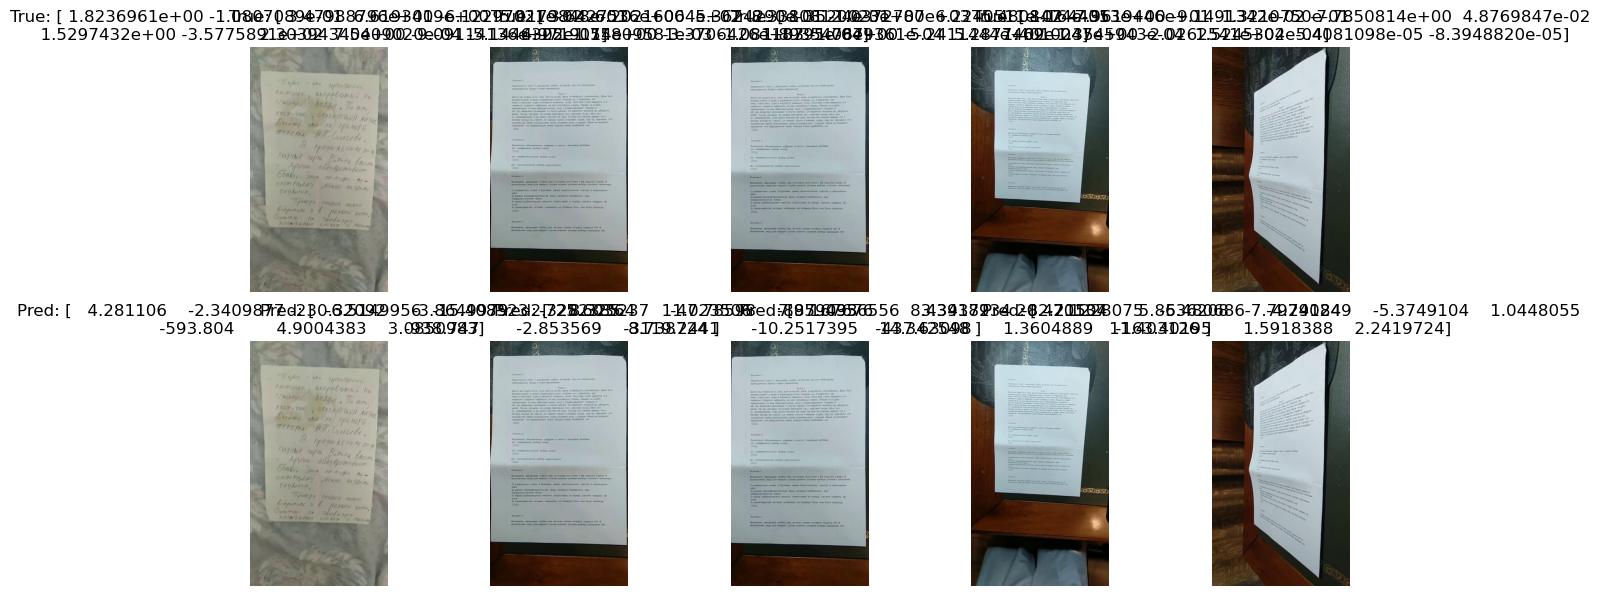

Выровненное изображение сохранено как peper/extracted_frames/aligned_test_image.png.


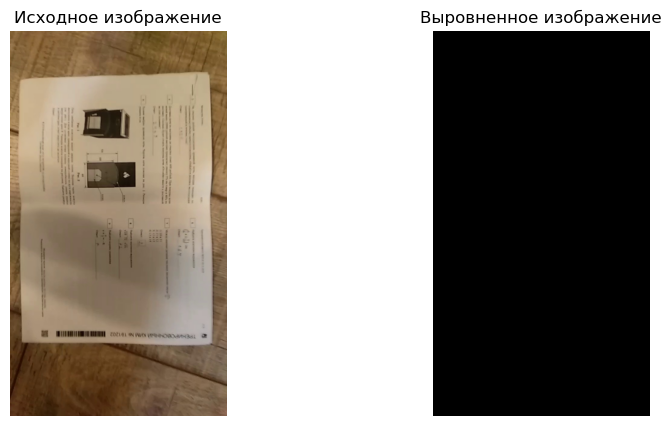

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH +'homography_data.csv'

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
display(train_df.head())

# Преобразование данных
train_images = [cv2.imread(img_path) for img_path in train_df['image_path']]
train_labels = train_df.iloc[:, 1:].values  # Параметры гомографии

# Функция для отображения изображений
def display_images(images, labels, rows=2, cols=5):
    fig = plt.figure(figsize=(15, 7))
    for index in range(rows * cols):
        ax = fig.add_subplot(rows, cols, index + 1)
        ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Params: {labels[index]}")
        ax.axis('off')
    plt.show()

display_images(train_images, train_labels)

# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)

# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)

        if self.transform:
            inp = self.transform(inp)

        return inp, out

# Преобразования для изображений
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Создание датасетов и загрузчиков
train_dataset = CreateDataset(train_images, train_labels, transform=t)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

test_dataset = CreateDataset(test_images, test_labels, transform=t)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32)

# Архитектура модели
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64 * 62 * 62, 512)
        self.fc2 = nn.Linear(512, 8)  # 8 параметров гомографии

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))
        x = self.relu(self.pool(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Обучение модели
EPOCHS = 20
net = Net()
criterion = nn.MSELoss()  # Среднеквадратичная ошибка для регрессии
optimizer = Adam(net.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    print(f"Epoch: {epoch + 1}, Train Loss: {running_loss / len(train_loader)}")

# Тестирование модели
net.eval()
test_loss = 0.0
pred_y = []
test_y = []

for data in test_loader:
    X_test, y_test = data
    with torch.no_grad():
        output = net(X_test)
        test_loss += criterion(output, y_test).item()
        pred_y.append(output.numpy())
        test_y.append(y_test.numpy())

print(f"Test Loss: {test_loss / len(test_loader)}")

# Преобразование результатов
pred_y = np.concatenate(pred_y)
test_y = np.concatenate(test_y)

# Визуализация результатов
def display_results(pred_y, test_y):
    fig = plt.figure(figsize=(15, 7))
    for i in range(5):
        ax = fig.add_subplot(2, 5, i + 1)
        ax.imshow(cv2.cvtColor(test_images[i], cv2.COLOR_BGR2RGB))
        ax.set_title(f"True: {test_y[i]}")
        ax.axis('off')

        ax = fig.add_subplot(2, 5, i + 6)
        ax.imshow(cv2.cvtColor(test_images[i], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Pred: {pred_y[i]}")
        ax.axis('off')
    plt.show()

display_results(pred_y, test_y)

# Тестирование на конкретном изображении
def test_single_image(image_path, model, output_path):
    # Преобразования для изображения
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Загрузка и предобработка изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

    # Предсказываем параметры гомографии
    with torch.no_grad():
        predicted_params = model(image_tensor)

    # Преобразуем параметры в матрицу гомографии
    predicted_params = predicted_params.numpy().flatten()
    M = np.append(predicted_params, 1.0).reshape(3, 3)

    # Выравниваем изображение
    height, width = image.shape[:2]
    aligned_image = cv2.warpPerspective(image, M, (width, height))

    # Сохраняем результат
    cv2.imwrite(output_path, aligned_image)
    print(f"Выровненное изображение сохранено как {output_path}.")

    # Показываем результат
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Исходное изображение")
    ax[0].axis('off')

    ax[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Выровненное изображение")
    ax[1].axis('off')

    plt.show()

# Пример использования
test_image_path = "peper/extracted_frames/4frame_0103.jpg"  # Путь к тестовому изображению
output_image_path = "peper/extracted_frames/aligned_test_image.png"  # Путь для сохранения результата
test_single_image(test_image_path, net, output_image_path)